In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = "http://quotes.toscrape.com/page/{}/"

data = []
page = 1

while True:
    url = base_url.format(page)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    quotes = soup.find_all("div", class_="quote")

    # Stop when no quotes found
    if not quotes:
        break

    for quote in quotes:
        text = quote.find("span", class_="text").text
        author = quote.find("small", class_="author").text

        data.append({
            "quote": text,
            "author": author,
            "page": page
        })

    print(f"Scraped page {page}")
    page += 1

# Convert to DataFrame
df = pd.DataFrame(data)

# Save file
df.to_csv("all_quotes.csv", index=False)

print(df.head())
print("Total quotes:", len(df))

Scraped page 1
Scraped page 2
Scraped page 3
Scraped page 4
Scraped page 5
Scraped page 6
Scraped page 7
Scraped page 8
Scraped page 9
Scraped page 10
                                               quote           author  page
0  “The world as we have created it is a process ...  Albert Einstein     1
1  “It is our choices, Harry, that show what we t...     J.K. Rowling     1
2  “There are only two ways to live your life. On...  Albert Einstein     1
3  “The person, be it gentleman or lady, who has ...      Jane Austen     1
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe     1
Total quotes: 100


In [6]:
import os

print(os.listdir())

['.config', 'all_quotes.csv', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_csv("all_quotes.csv")
df.head()

,quote,author,page
0,“The world as we have created it is a process ...,Albert Einstein,1
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,1
2,“There are only two ways to live your life. On...,Albert Einstein,1
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,1
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,1


In [9]:
df.shape

(100, 3)

In [10]:
df.columns

Index(['quote', 'author', 'page'], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   quote   100 non-null    object
 1   author  100 non-null    object
 2   page    100 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [12]:
df.isnull().sum()

,0
quote,0
author,0
page,0


In [13]:
df["author"].nunique()

50

In [14]:
top_authors = df["author"].value_counts()

print(top_authors.head(10))

author
Albert Einstein      10
J.K. Rowling          9
Marilyn Monroe        7
Dr. Seuss             6
Mark Twain            6
Jane Austen           5
C.S. Lewis            5
Bob Marley            3
Mother Teresa         2
Eleanor Roosevelt     2
Name: count, dtype: int64


In [15]:
df["page"].value_counts().sort_index()

,count
page,
1,10
2,10
3,10
4,10
5,10
6,10
7,10
8,10
9,10


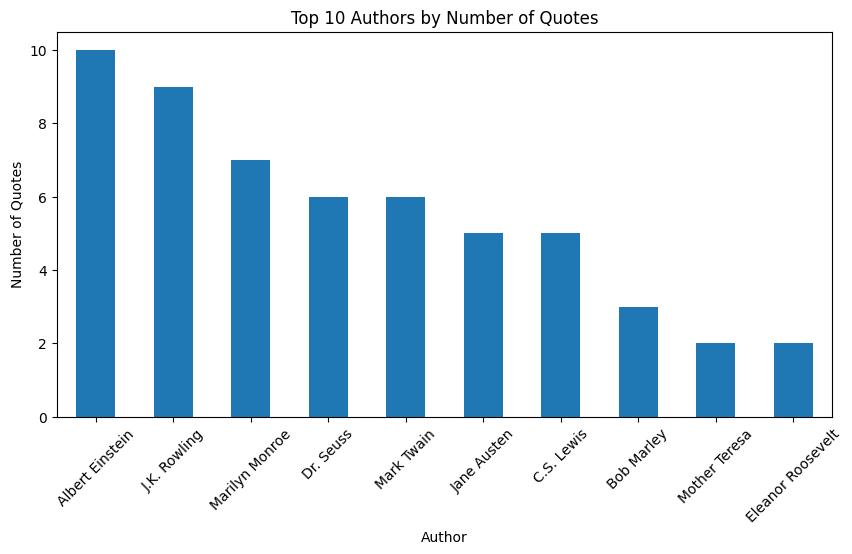

In [16]:
import matplotlib.pyplot as plt

top_authors = df["author"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_authors.plot(kind="bar")
plt.title("Top 10 Authors by Number of Quotes")
plt.xlabel("Author")
plt.ylabel("Number of Quotes")
plt.xticks(rotation=45)
plt.show()

                                                           Task Three

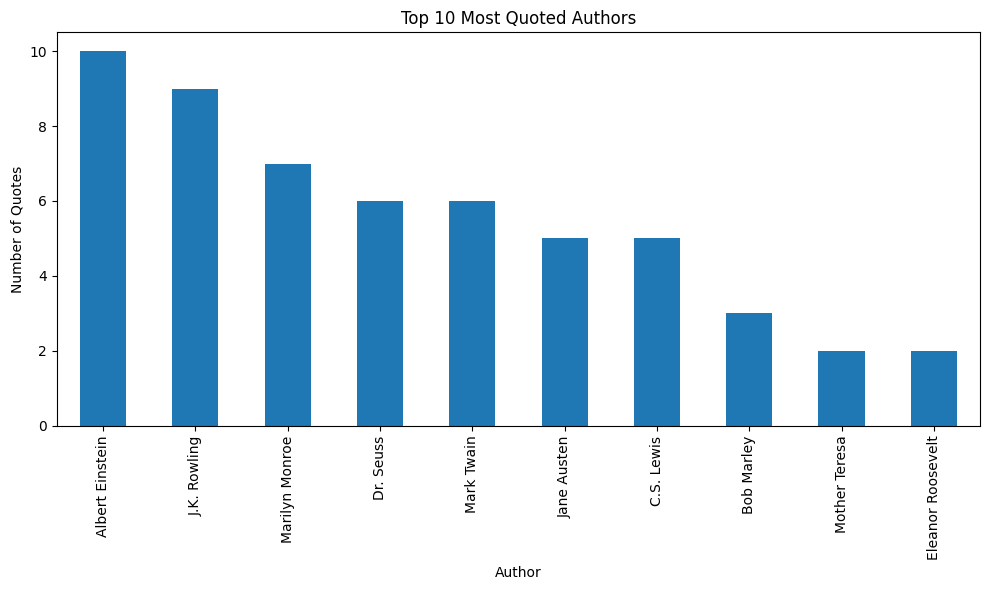

In [17]:
import matplotlib.pyplot as plt

top10 = df["author"].value_counts().head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")

plt.title("Top 10 Most Quoted Authors")
plt.xlabel("Author")
plt.ylabel("Number of Quotes")

plt.tight_layout()
plt.show()

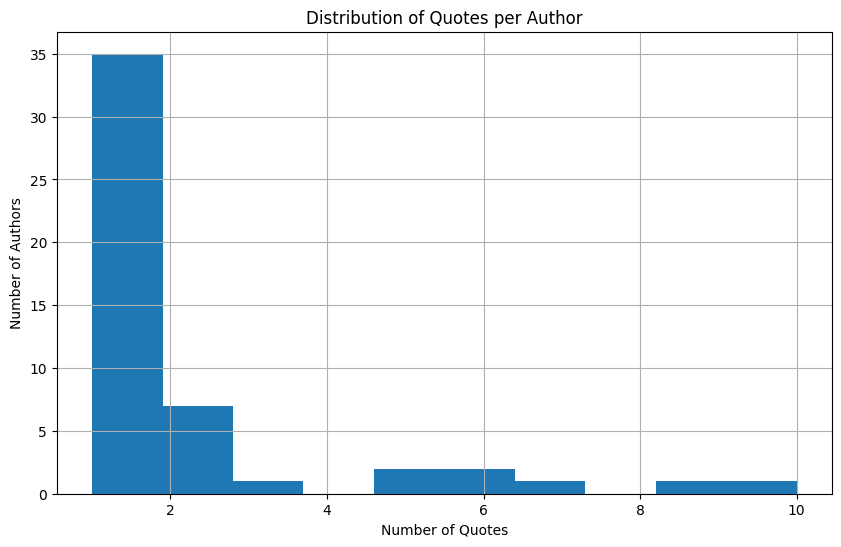

In [18]:
plt.figure(figsize=(10,6))

df["author"].value_counts().hist(bins=10)

plt.title("Distribution of Quotes per Author")
plt.xlabel("Number of Quotes")
plt.ylabel("Number of Authors")

plt.show()

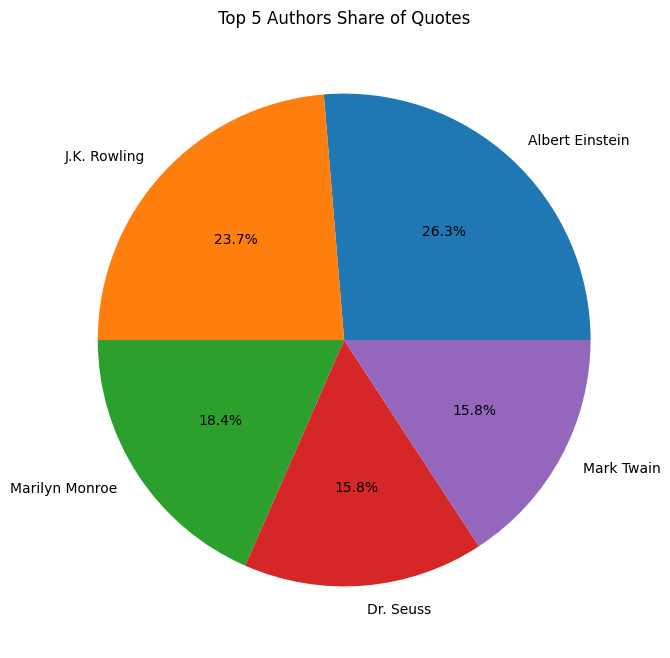

In [19]:
top5 = df["author"].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%'
)

plt.title("Top 5 Authors Share of Quotes")
plt.show()

**Task four**

In [20]:
!pip install textblob

In [21]:
import pandas as pd

df = pd.read_csv("all_quotes.csv")

df.head()

,quote,author,page
0,“The world as we have created it is a process ...,Albert Einstein,1
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,1
2,“There are only two ways to live your life. On...,Albert Einstein,1
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,1
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,1


In [23]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [24]:
df["Sentiment"] = df["quote"].apply(get_sentiment)

df.head()

,quote,author,page,Sentiment
0,“The world as we have created it is a process ...,Albert Einstein,1,Neutral
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,1,Positive
2,“There are only two ways to live your life. On...,Albert Einstein,1,Positive
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,1,Negative
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,1,Negative


In [25]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    54
Neutral     28
Negative    18
Name: count, dtype: int64


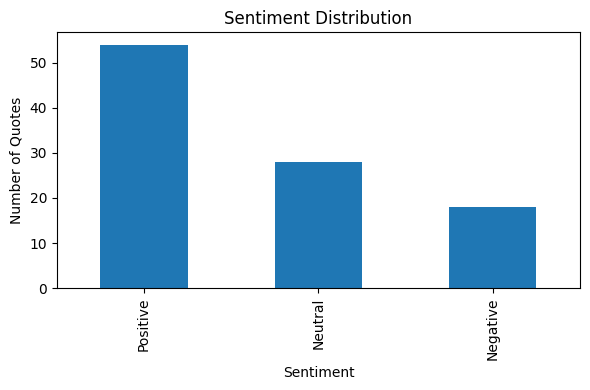

In [26]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Quotes")

plt.tight_layout()
plt.show()

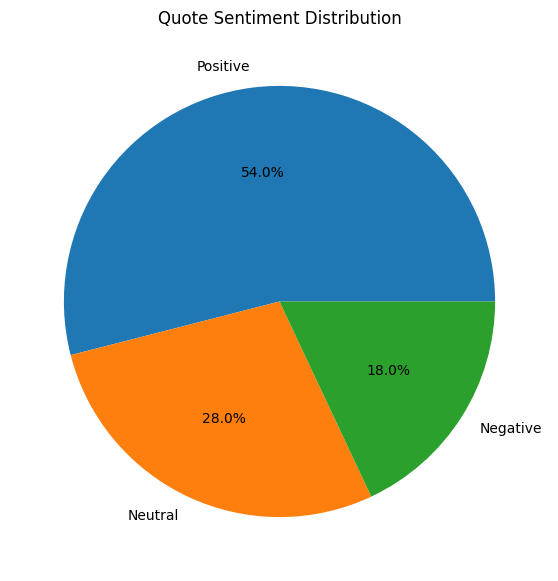

In [27]:
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Quote Sentiment Distribution")
plt.show()

In [28]:
df.to_csv("quotes_with_sentiment.csv", index=False)

In [29]:
from google.colab import files
files.download("quotes_with_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>